In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [4]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Deep Learning/exp1-DL - Sheet1.csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values
print(X)
print(y)

[[  25]
 [  62]
 [  14]
 [  17]
 [  99]
 [  63]
 [9725]
 [  26]
 [  91]
 [ 678]
 [ 659]
 [  28]
 [  54]
 [ 513]]
[[  62]
 [  93]
 [ 741]
 [ 123]
 [ 369]
 [ 987]
 [ 568]
 [ 271]
 [ 918]
 [  27]
 [ 852]
 [1999]
 [1997]
 [2005]]


In [5]:
dataset1.head()

,Input,Output
0,25,62
1,62,93
2,14,741
3,17,123
4,99,369


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [7]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [12]:
# Name: RIYA P L
# Register Number: 212223240141
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        # Include your code here

        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss': []}

  def forward(self,X):
    X=self.relu(self.fc1(X))
    X=self.relu(self.fc2(X))
    X=self.fc3(X)
    return X

In [13]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig=NeuralNet()
criterion=nn.MSELoss()
optimizer=optim.RMSprop (lig. parameters(), lr=0.001)

In [14]:
# Name: RIYA P L
# Register Number: 212223240141
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    # Write your code here
    for epoch in range (epochs):
      optimizer.zero_grad()
      loss=criterion(ai_brain(X_train),y_train)
      loss.backward()
      optimizer.step()
      lig.history['loss'].append(loss.item())
      if epoch%200==0 :
        print(f'Epoch [{epoch}/{epochs}],Loss: {loss.item()}:.6f)')

In [15]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000],Loss: 848298.5625:.6f)
Epoch [200/2000],Loss: 843059.1875:.6f)
Epoch [400/2000],Loss: 832300.0625:.6f)
Epoch [600/2000],Loss: 812389.4375:.6f)
Epoch [800/2000],Loss: 783518.1875:.6f)
Epoch [1000/2000],Loss: 745295.875:.6f)
Epoch [1200/2000],Loss: 698071.0:.6f)
Epoch [1400/2000],Loss: 643060.5625:.6f)
Epoch [1600/2000],Loss: 582465.6875:.6f)
Epoch [1800/2000],Loss: 519541.375:.6f)


In [16]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 1166340.125000


In [17]:
loss_df = pd.DataFrame(lig.history)

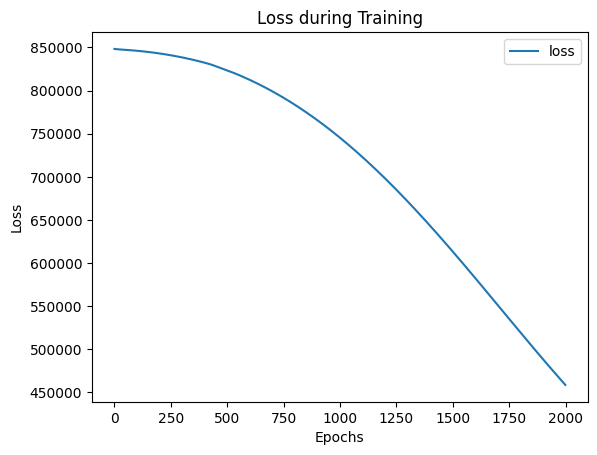

In [18]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [20]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 316.3855285644531
